# Lecture 7 · Regularization lab: what each remedy changes

**You will** compare a brittle and a regularized 2-D classifier, test one augmentation claim on the same ring, inspect the two arrows in a weight-decay update, implement inverted dropout, and calculate mixup and label-smoothed targets.

> Change one mechanism at a time. A regularizer earns its place only if validation improves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(17)
plt.rcParams.update({'figure.figsize': (7, 4.5), 'axes.grid': True})

## 1 · A small training set makes memorization tempting

We classify points inside or outside a noisy ring. The validation set is much larger, so a boundary that chases individual training points is exposed.

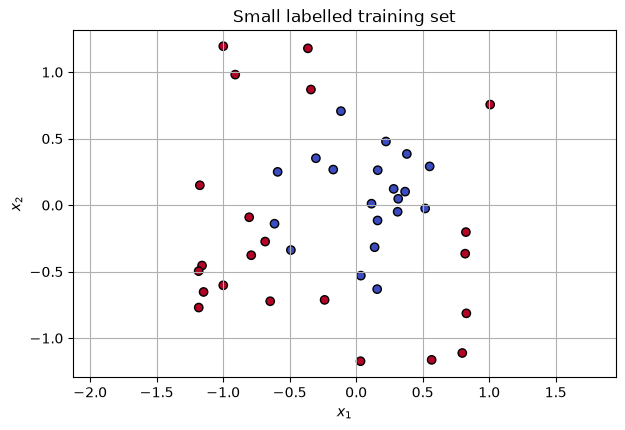

In [2]:
def make_ring(n, rng):
    X = rng.uniform(-1.2, 1.2, size=(n, 2))
    radius = np.sqrt((X ** 2).sum(axis=1))
    y = (radius > 0.72).astype(float)
    flip = rng.random(n) < 0.07
    y[flip] = 1 - y[flip]
    return X, y

X_tr, y_tr = make_ring(42, rng)
X_va, y_va = make_ring(600, rng)
plt.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap='coolwarm', edgecolor='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.title('Small labelled training set')
plt.axis('equal'); plt.show()

## 2 · Weight decay chooses a less brittle fitting solution

We use polynomial features up to degree 7. **Predict:** which run should have the smaller weight norm? Which run might have slightly worse training loss but better validation loss?

In [3]:
def features(X, degree=7):
    x1, x2 = X[:, 0], X[:, 1]
    cols = [np.ones(len(X))]
    for total in range(1, degree + 1):
        for a in range(total + 1):
            cols.append((x1 ** a) * (x2 ** (total - a)))
    return np.column_stack(cols)

Phi_tr, Phi_va = features(X_tr), features(X_va)
mu, sd = Phi_tr[:, 1:].mean(0), Phi_tr[:, 1:].std(0) + 1e-8
def scale(Phi):
    Q = Phi.copy(); Q[:, 1:] = (Q[:, 1:] - mu) / sd
    return Q
Phi_tr, Phi_va = scale(Phi_tr), scale(Phi_va)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

def cross_entropy(Phi, y, w):
    p = np.clip(sigmoid(Phi @ w), 1e-8, 1 - 1e-8)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def fit_decay(decay, steps=5000, lr=0.025):
    w = np.zeros(Phi_tr.shape[1])
    history = []
    for step in range(steps):
        p = sigmoid(Phi_tr @ w)
        grad = Phi_tr.T @ (p - y_tr) / len(y_tr)
        w[1:] *= (1 - lr * decay)
        w -= lr * grad
        if step % 100 == 0:
            history.append((cross_entropy(Phi_tr, y_tr, w), cross_entropy(Phi_va, y_va, w), np.linalg.norm(w[1:])))
    return w, np.array(history)

runs = {lam: fit_decay(lam) for lam in [0.0, 0.03, 0.2]}
print('decay | train CE | validation CE | weight norm')
for lam, (w, hist) in runs.items():
    print(f'{lam:>5.2f} | {cross_entropy(Phi_tr,y_tr,w):>8.3f} | {cross_entropy(Phi_va,y_va,w):>13.3f} | {np.linalg.norm(w[1:]):>11.3f}')

decay | train CE | validation CE | weight norm
 0.00 |    0.071 |         0.596 |       4.921
 0.03 |    0.165 |         0.456 |       2.195
 0.20 |    0.305 |         0.482 |       0.928


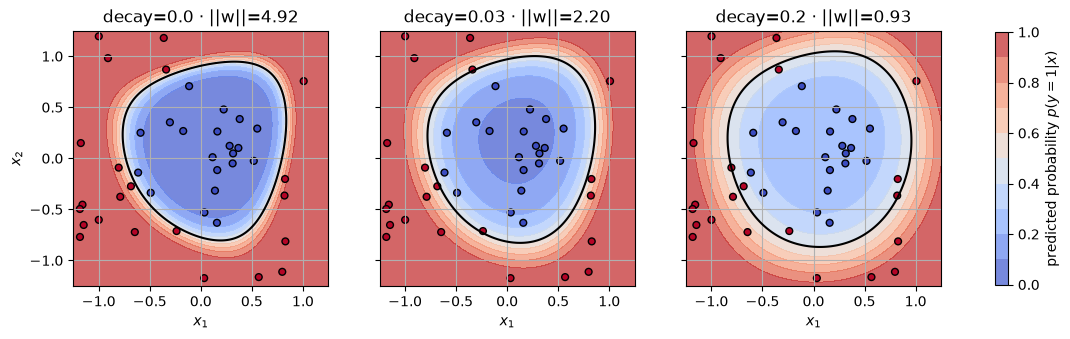

In [4]:
gx, gy = np.meshgrid(np.linspace(-1.25, 1.25, 220), np.linspace(-1.25, 1.25, 220))
G = np.column_stack([gx.ravel(), gy.ravel()])
Phi_g = scale(features(G))
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, (lam, (w, _)) in zip(axes, runs.items()):
    prob = sigmoid(Phi_g @ w).reshape(gx.shape)
    image = ax.contourf(gx, gy, prob, levels=np.linspace(0, 1, 11), cmap='coolwarm', alpha=.75)
    ax.contour(gx, gy, prob, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap='coolwarm', edgecolor='k', s=24)
    ax.set_title(f'decay={lam} · ||w||={np.linalg.norm(w[1:]):.2f}')
    ax.set_xlabel('$x_1$'); ax.set_aspect('equal')
axes[0].set_ylabel('$x_2$')
fig.colorbar(image, ax=axes, label='predicted probability $p(y=1|x)$', shrink=.82)
plt.show()

**Explain:** Point to a boundary feature that disappears as decay increases. Use the printed train loss, validation loss, and norm to decide whether $\lambda=0.2$ is useful or excessive.

## 3 · Check an augmentation claim on the same ring

A valid augmentation changes a nuisance while preserving the task label. **Predict before running:** for a ring centred at the origin, should rotation about the origin preserve every clean label? Should translating every point by $[0.35,0]$?

The cell recomputes labels from the known clean ring rule only as an **oracle diagnostic** of whether each proposed transform is label-preserving. It does not create training targets. In actual augmentation, a valid transform keeps the original label; if the diagnostic says labels change, reject that transform.

In [5]:
def clean_ring_label(X):
    return (np.sqrt((X ** 2).sum(axis=1)) > 0.72).astype(int)

angle = np.deg2rad(37)
rotation = np.array([[np.cos(angle), -np.sin(angle)],
                     [np.sin(angle),  np.cos(angle)]])
X_rotated = X_va @ rotation.T
X_translated = X_va + np.array([0.35, 0.0])

# Recompute clean labels only to diagnose the transform; never use these as augmented training targets.
reference = clean_ring_label(X_va)
rotation_agreement = np.mean(clean_ring_label(X_rotated) == reference)
translation_agreement = np.mean(clean_ring_label(X_translated) == reference)
print(f'rotation label agreement    = {rotation_agreement:.3f}')
print(f'translation label agreement = {translation_agreement:.3f}')

assert rotation_agreement == 1.0
assert translation_agreement < 1.0

rotation label agreement    = 1.000
translation label agreement = 0.838


## 4 · Separate the two arrows in one decay update

For $\theta=5$, data gradient $g=3$, learning rate $\eta=0.1$, and decay rate $\lambda'=0.2$, calculate the shrink contribution and the data-gradient contribution before running.

In [6]:
theta, gradient, eta, decay = 5.0, 3.0, 0.1, 0.2
after_shrink = (1 - eta * decay) * theta
theta_next = after_shrink - eta * gradient
print(f'shrink factor             = {1 - eta * decay:.2f}')
print(f'weight after shrink        = {after_shrink:.2f}')
print(f'data-gradient contribution = {-eta * gradient:.2f}')
print(f'new weight                 = {theta_next:.2f}')

shrink factor             = 0.98
weight after shrink        = 4.90
data-gradient contribution = -0.30
new weight                 = 4.60


## 5 · Implement inverted dropout and verify its expectation

The remaining dropout, mixup, and smoothing sections are isolated mechanism checks; they do not claim a validation improvement on the ring classifier.

For $h=[2,4,6,8]$, keep probability $p_{keep}=0.5$, and mask $[1,0,1,0]$, predict the training output. Then average many random masks and compare with the original $h$. Here the lecture's $p$ means **keep probability**. PyTorch `nn.Dropout(p=...)` instead names the **drop probability**, so $p_{PyTorch}=1-p_{keep}$.

In [7]:
def dropout(h, keep_probability, training, rng):
    if not training:
        return h.copy()
    mask = (rng.random(h.shape) < keep_probability).astype(float)
    return mask * h / keep_probability

h = np.array([2., 4., 6., 8.])
fixed_mask = np.array([1., 0., 1., 0.])
print('fixed-mask output =', fixed_mask * h / 0.5)
samples = np.array([dropout(h, 0.5, True, rng) for _ in range(50000)])
print('Monte-Carlo mean  =', np.round(samples.mean(axis=0), 3))
print('evaluation output =', dropout(h, 0.5, False, rng))

fixed-mask output = [ 4.  0. 12.  0.]
Monte-Carlo mean  = [2.011 4.009 6.045 8.046]
evaluation output = [2. 4. 6. 8.]


## 6 · Mix inputs and targets together

A cat target is $[1,0]$, a dog target is $[0,1]$, and $\lambda=0.7$. Calculate the mixed target and its cross-entropy for $p=[0.8,0.2]$.

In [8]:
lam = 0.7
cat, dog = np.array([1., 0.]), np.array([0., 1.])
mixed_target = lam * cat + (1 - lam) * dog
prediction = np.array([0.8, 0.2])
loss = -np.sum(mixed_target * np.log(prediction))
print('mixed target =', mixed_target)
print(f'soft cross-entropy = {loss:.3f}')

mixed target = [0.7 0.3]
soft cross-entropy = 0.639


## 7 · Smooth a hard target

For $K=5$, $\epsilon=0.1$, and correct class index 2 (the third class), calculate the target. Then compare the loss of an extremely confident prediction under hard and smoothed supervision.

In [9]:
K, epsilon, correct = 5, 0.1, 2
smooth = np.full(K, epsilon / (K - 1))
smooth[correct] = 1 - epsilon
hard = np.eye(K)[correct]
prediction = np.full(K, 0.005); prediction[correct] = 0.98
hard_loss = -np.sum(hard * np.log(prediction))
smooth_loss = -np.sum(smooth * np.log(prediction))
print('smoothed target =', smooth, 'sum =', smooth.sum())
print(f'hard-label loss = {hard_loss:.3f}')
print(f'smoothed loss   = {smooth_loss:.3f}')

smoothed target = [0.025 0.025 0.9   0.025 0.025] sum = 1.0
hard-label loss = 0.020
smoothed loss   = 0.548


## Exit check

Weight decay and augmentation used the persistent ring case. Dropout, mixup, and label smoothing were mechanism-only arithmetic checks here, not trained ring comparisons.

For each mechanism, name what it changes: weight decay, dropout, augmentation/mixup, label smoothing, and early stopping. Then choose one observed failure from this notebook and justify a single first remedy using validation evidence.